In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import math
import os
import re
import csv


def heatmap(data, row_labels, col_labels, ax, cbarlabel, **kwargs):
    """
    Creates a heatmap from a numpy array and row/column label lists.

    Args:
        data:       2D numpy array of shape (n_rows, n_cols).
        row_labels: List of labels for rows (Y axis).
        col_labels: List of labels for columns (X axis).
        ax:         matplotlib Axes instance.
        cbarlabel:  Label for the colorbar.
        **kwargs:   Forwarded to imshow.
    Returns:
        im, cbar
    """
    im = ax.imshow(data, origin='lower', **kwargs)

    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel(cbarlabel, rotation=-90, va="bottom")

    ax.set_xticks(range(data.shape[1]), labels=col_labels)
    ax.set_xlabel('Column')
    ax.set_yticks(range(data.shape[0]), labels=row_labels)
    ax.set_ylabel('Row')

    ax.spines[:].set_visible(False)
    ax.set_xticks(np.arange(data.shape[1] + 1) - .5, minor=True)
    ax.set_yticks(np.arange(data.shape[0] + 1) - .5, minor=True)
    ax.grid(which="minor", color="w", linestyle='-', linewidth=3)
    ax.tick_params(which="minor", bottom=False, left=False)

    return im, cbar


def annotate_heatmap(im, data=None, valfmt="{x:.4f}",
                     textcolors=("white", "black"), threshold=None,
                     skip_mask=None, **textkw):
    """
    Annotates each cell of a heatmap with its value (or 'NaN').

    Args:
        im:          AxesImage returned by heatmap().
        data:        Data to annotate; defaults to image data.
        valfmt:      Format string for values.
        textcolors:  (dark_bg_color, light_bg_color). Cells below the colormap
                     midpoint (dark) use textcolors[0]; above (bright) use [1].
        threshold:   Explicit normalised pivot; defaults to 0.5 (colormap mid).
        skip_mask:   2D bool array; True cells are skipped entirely (no text).
        **textkw:    Forwarded to ax.text().
    """
    if not isinstance(data, (list, np.ndarray)):
        data = im.get_array()

    # Use 0.5 as default — the colormap midpoint, independent of data range.
    # (Computing from data.max() breaks when outlier values inflate im.norm.)
    threshold = 0.5 if threshold is None else im.norm(threshold)

    kw = dict(horizontalalignment="center", verticalalignment="center")
    kw.update(textkw)

    if isinstance(valfmt, str):
        valfmt = mpl.ticker.StrMethodFormatter(valfmt)

    texts = []
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if skip_mask is not None and skip_mask[i, j]:
                continue
            if math.isnan(data[i, j]):
                nan_kw = {k: v for k, v in kw.items() if k != 'color'}
                text = im.axes.text(j, i, 'NaN', color='black', **nan_kw)
            else:
                kw.update(color=textcolors[int(im.norm(data[i, j]) > threshold)])
                text = im.axes.text(j, i, valfmt(data[i, j], None), **kw)
            texts.append(text)
    return texts


def valid_range(grid, outlier_mask):
    """Return (vmin, vmax) ignoring NaN and outlier cells."""
    valid = grid[~np.isnan(grid) & ~outlier_mask]
    return (float(valid.min()), float(valid.max())) if len(valid) else (0.0, 1.0)


def add_outlier_patches(ax, outlier_mask, label="OVL"):
    """Overlay a red square and label on each outlier cell, on top of all annotations."""
    for ri in range(outlier_mask.shape[0]):
        for ci in range(outlier_mask.shape[1]):
            if outlier_mask[ri, ci]:
                ax.add_patch(mpl.patches.Rectangle(
                    (ci - 0.5, ri - 0.5), 1, 1,
                    color='red', zorder=10
                ))
                ax.text(ci, ri, label,
                        ha='center', va='center', color='white',
                        fontsize=8, fontweight='bold', zorder=11)


In [2]:
# ---------------------------------------------------------------------------
# Data loading  (most recent date wins for duplicate die locations)
# ---------------------------------------------------------------------------
# Path to WaferMapR folder, relative to this notebook (notebooks/ -> data/)
data_root = os.path.join('..', 'data', 'WaferMapR')

# Folder names follow the pattern D<row><col><device>, e.g. D162 = row 1, col 6, device 2
folder_pattern = re.compile(r'^D(\d)(\d)(\d)$')

# {(row, col, device): mean_resistance}
resistance_data = {}
# {(row, col, device): std_resistance}
std_data = {}
# {(row, col, device): date_folder string} — tracks which date each entry came from
date_seen = {}

for date_folder in sorted(os.listdir(data_root)):
    date_path = os.path.join(data_root, date_folder)
    if not os.path.isdir(date_path):
        continue
    for die_folder in sorted(os.listdir(date_path)):
        m = folder_pattern.match(die_folder)
        if not m:
            continue
        row, col, device = int(m.group(1)), int(m.group(2)), int(m.group(3))
        key = (row, col, device)

        # Skip if we already have data from a more recent date
        if key in date_seen and date_seen[key] >= date_folder:
            continue

        csv_path = os.path.join(date_path, die_folder, 'TimevsRes.csv')
        if not os.path.isfile(csv_path):
            continue
        resistances = []
        with open(csv_path, 'r') as f:
            reader = csv.reader(f)
            for row_data in reader:
                if len(row_data) >= 2:
                    try:
                        resistances.append(float(row_data[1]))
                    except ValueError:
                        pass  # skip any non-numeric header lines
        if resistances:
            resistance_data[key] = abs(np.mean(resistances))
            std_data[key] = np.std(resistances)
            date_seen[key] = date_folder

print(f"Loaded {len(resistance_data)} die/device measurements")
for key in sorted(resistance_data):
    print(f"  Row {key[0]}, Col {key[1]}, Device {key[2]} [{date_seen[key]}]: mean={resistance_data[key]:.6f} Ohms  std={std_data[key]:.6f} Ohms")


Loaded 113 die/device measurements
  Row 0, Col 1, Device 1 [20260422]: mean=0.344767 Ohms  std=0.001349 Ohms
  Row 0, Col 1, Device 2 [20260422]: mean=0.353388 Ohms  std=0.001201 Ohms
  Row 0, Col 2, Device 1 [20260422]: mean=0.345066 Ohms  std=0.000927 Ohms
  Row 0, Col 2, Device 2 [20260422]: mean=0.348847 Ohms  std=0.001309 Ohms
  Row 0, Col 3, Device 1 [20260423]: mean=0.051536 Ohms  std=0.143714 Ohms
  Row 0, Col 3, Device 2 [20260423]: mean=1161083.575000 Ohms  std=18730.860319 Ohms
  Row 0, Col 4, Device 1 [20260423]: mean=0.355752 Ohms  std=0.000749 Ohms
  Row 0, Col 4, Device 2 [20260423]: mean=0.357614 Ohms  std=0.001268 Ohms
  Row 0, Col 5, Device 1 [20260423]: mean=0.377084 Ohms  std=0.000358 Ohms
  Row 0, Col 5, Device 2 [20260423]: mean=0.377796 Ohms  std=0.000930 Ohms
  Row 1, Col 0, Device 1 [20260423]: mean=0.341423 Ohms  std=0.001264 Ohms
  Row 1, Col 0, Device 2 [20260423]: mean=0.340161 Ohms  std=0.000497 Ohms
  Row 1, Col 1, Device 1 [20260413]: mean=0.341821 Ohms

C:\Users\Gabe\AppData\Local\Temp\ipykernel_3648\3469189196.py:77: UserWarning: Warning: converting a masked element to nan.
  if math.isnan(data[i, j]):
C:\Users\Gabe\AppData\Local\Temp\ipykernel_3648\3469189196.py:77: UserWarning: Warning: converting a masked element to nan.
  if math.isnan(data[i, j]):


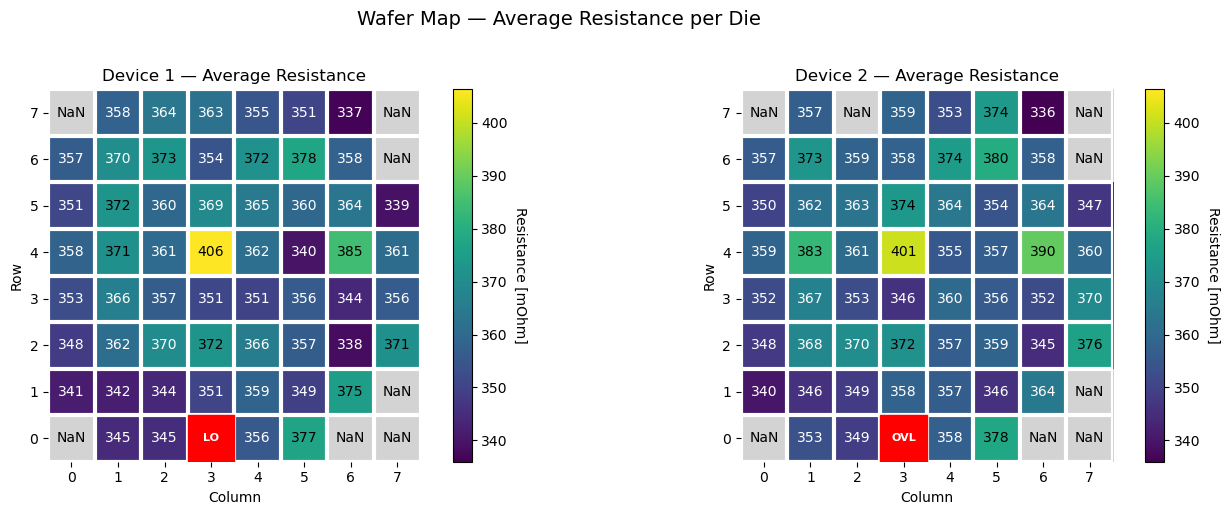

In [ ]:
# ---------------------------------------------------------------------------
# Build 2D grids and plot wafer maps
# ---------------------------------------------------------------------------
all_rows = sorted({k[0] for k in resistance_data})
all_cols = sorted({k[1] for k in resistance_data})

n_rows = len(all_rows)
n_cols = len(all_cols)

row_idx = {r: i for i, r in enumerate(all_rows)}
col_idx = {c: i for i, c in enumerate(all_cols)}

grid_dev1 = np.full((n_rows, n_cols), np.nan)
grid_dev2 = np.full((n_rows, n_cols), np.nan)

for (row, col, device), avg_res in resistance_data.items():
    ri = row_idx[row]
    ci = col_idx[col]
    if device == 1:
        grid_dev1[ri, ci] = avg_res
    elif device == 2:
        grid_dev2[ri, ci] = avg_res

# Convert Ohm → mOhm
grid_dev1 = grid_dev1 * 1000
grid_dev2 = grid_dev2 * 1000

# Out-of-range masks
OUTLIER_THRESHOLD = 1e9   # > 1 MOhm (in mOhm) → labeled OVL
LOWER_THRESHOLD   = 60    # < 60 mOhm           → labeled LO

outlier_mask_dev1    = ~np.isnan(grid_dev1) & (grid_dev1 > OUTLIER_THRESHOLD)
outlier_mask_dev2    = ~np.isnan(grid_dev2) & (grid_dev2 > OUTLIER_THRESHOLD)
underrange_mask_dev1 = ~np.isnan(grid_dev1) & (grid_dev1 < LOWER_THRESHOLD)
underrange_mask_dev2 = ~np.isnan(grid_dev2) & (grid_dev2 < LOWER_THRESHOLD)
bad_mask_dev1 = outlier_mask_dev1 | underrange_mask_dev1
bad_mask_dev2 = outlier_mask_dev2 | underrange_mask_dev2

cmap = mpl.colormaps.get_cmap('viridis').copy()
cmap.set_bad(color='lightgrey')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

vmin1, vmax1 = valid_range(grid_dev1, bad_mask_dev1)
vmin2, vmax2 = valid_range(grid_dev2, bad_mask_dev2)
vmin = min(vmin1, vmin2)
vmax = max(vmax1, vmax2)

im1, cbar1 = heatmap(grid_dev1, all_rows, all_cols, ax=ax1,
                     cbarlabel="Resistance [mOhm]", cmap=cmap,
                     vmin=vmin, vmax=vmax)
annotate_heatmap(im1, valfmt="{x:.3g}", skip_mask=bad_mask_dev1)
add_outlier_patches(ax1, outlier_mask_dev1)
add_outlier_patches(ax1, underrange_mask_dev1, label="LO")
ax1.set_title("Test Structure 1 — Average Resistance")

im2, cbar2 = heatmap(grid_dev2, all_rows, all_cols, ax=ax2,
                     cbarlabel="Resistance [mOhm]", cmap=cmap,
                     vmin=vmin, vmax=vmax)
annotate_heatmap(im2, valfmt="{x:.3g}", skip_mask=bad_mask_dev2)
add_outlier_patches(ax2, outlier_mask_dev2)
add_outlier_patches(ax2, underrange_mask_dev2, label="LO")
ax2.set_title("Test Structure 2 — Average Resistance")

fig.suptitle("Wafer Map — Average Resistance per Die", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


C:\Users\Gabe\AppData\Local\Temp\ipykernel_3648\3469189196.py:77: UserWarning: Warning: converting a masked element to nan.
  if math.isnan(data[i, j]):
C:\Users\Gabe\AppData\Local\Temp\ipykernel_3648\3469189196.py:77: UserWarning: Warning: converting a masked element to nan.
  if math.isnan(data[i, j]):


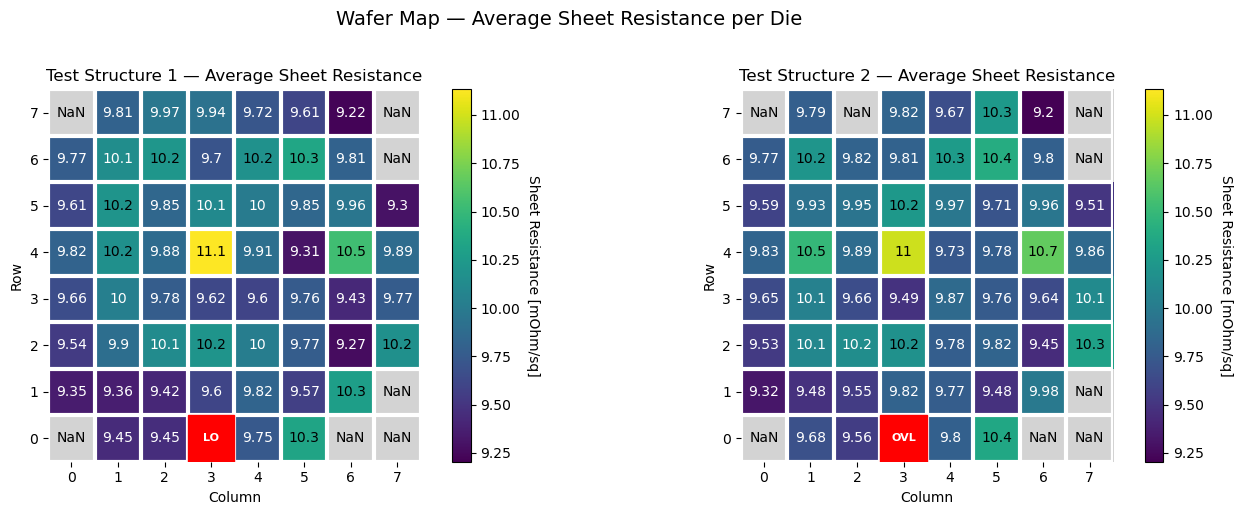

In [4]:
# ---------------------------------------------------------------------------
# Sheet resistance wafer maps  (Rs = R * W/L = R * 12/438)
# ---------------------------------------------------------------------------
CORRECTION = 12 / 438  # W/L factor for 4-pt probe structure (W=12 um, L=438 um)

grid_rs_dev1 = grid_dev1 * CORRECTION
grid_rs_dev2 = grid_dev2 * CORRECTION

cmap_rs = mpl.colormaps.get_cmap('viridis').copy()
cmap_rs.set_bad(color='lightgrey')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

vmin1, vmax1 = valid_range(grid_rs_dev1, bad_mask_dev1)
vmin2, vmax2 = valid_range(grid_rs_dev2, bad_mask_dev2)
vmin = min(vmin1, vmin2)
vmax = max(vmax1, vmax2)

im1, cbar1 = heatmap(grid_rs_dev1, all_rows, all_cols, ax=ax1,
                     cbarlabel="Sheet Resistance [mOhm/sq]", cmap=cmap_rs,
                     vmin=vmin, vmax=vmax)
annotate_heatmap(im1, valfmt="{x:.3g}", skip_mask=bad_mask_dev1)
add_outlier_patches(ax1, outlier_mask_dev1)
add_outlier_patches(ax1, underrange_mask_dev1, label="LO")
ax1.set_title("Test Structure 1 — Average Sheet Resistance")

im2, cbar2 = heatmap(grid_rs_dev2, all_rows, all_cols, ax=ax2,
                     cbarlabel="Sheet Resistance [mOhm/sq]", cmap=cmap_rs,
                     vmin=vmin, vmax=vmax)
annotate_heatmap(im2, valfmt="{x:.3g}", skip_mask=bad_mask_dev2)
add_outlier_patches(ax2, outlier_mask_dev2)
add_outlier_patches(ax2, underrange_mask_dev2, label="LO")
ax2.set_title("Test Structure 2 — Average Sheet Resistance")

fig.suptitle("Wafer Map — Average Sheet Resistance per Die", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


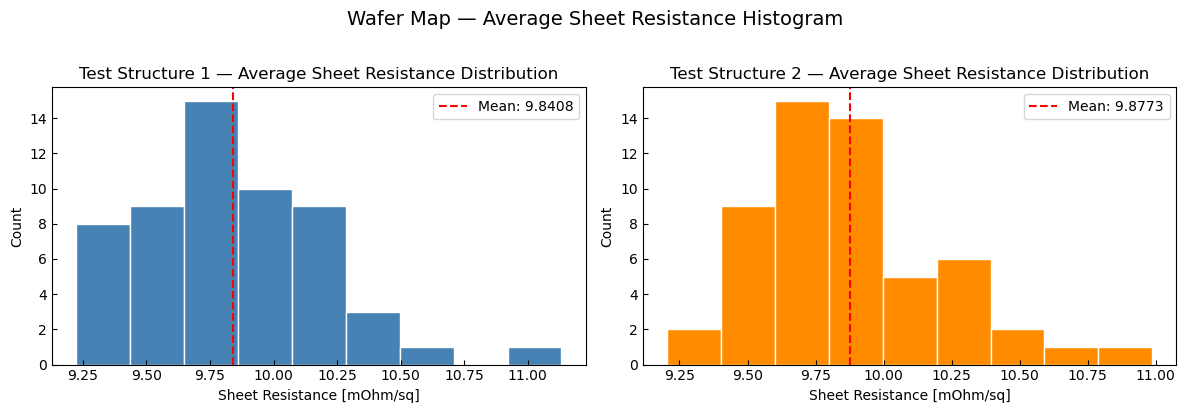

In [5]:
# ---------------------------------------------------------------------------
# Histograms of average sheet resistance (Device 1 and Device 2)
# ---------------------------------------------------------------------------
rs_vals_dev1 = grid_rs_dev1[~np.isnan(grid_rs_dev1) & ~bad_mask_dev1].flatten()
rs_vals_dev2 = grid_rs_dev2[~np.isnan(grid_rs_dev2) & ~bad_mask_dev2].flatten()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(rs_vals_dev1, bins='auto', color='steelblue', edgecolor='white')
ax1.set_title("Test Structure 1 — Average Sheet Resistance Distribution")
ax1.set_xlabel("Sheet Resistance [mOhm/sq]")
ax1.set_ylabel("Count")
ax1.tick_params(axis='both', which='both', direction='in')
ax1.axvline(np.mean(rs_vals_dev1), color='red', linestyle='--', linewidth=1.5, label=f"Mean: {np.mean(rs_vals_dev1):.4f}")
ax1.legend()

ax2.hist(rs_vals_dev2, bins='auto', color='darkorange', edgecolor='white')
ax2.set_title("Test Structure 2 — Average Sheet Resistance Distribution")
ax2.set_xlabel("Sheet Resistance [mOhm/sq]")
ax2.set_ylabel("Count")
ax2.tick_params(axis='both', which='both', direction='in')
ax2.axvline(np.mean(rs_vals_dev2), color='red', linestyle='--', linewidth=1.5, label=f"Mean: {np.mean(rs_vals_dev2):.4f}")
ax2.legend()

fig.suptitle("Wafer Map — Average Sheet Resistance Histogram", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


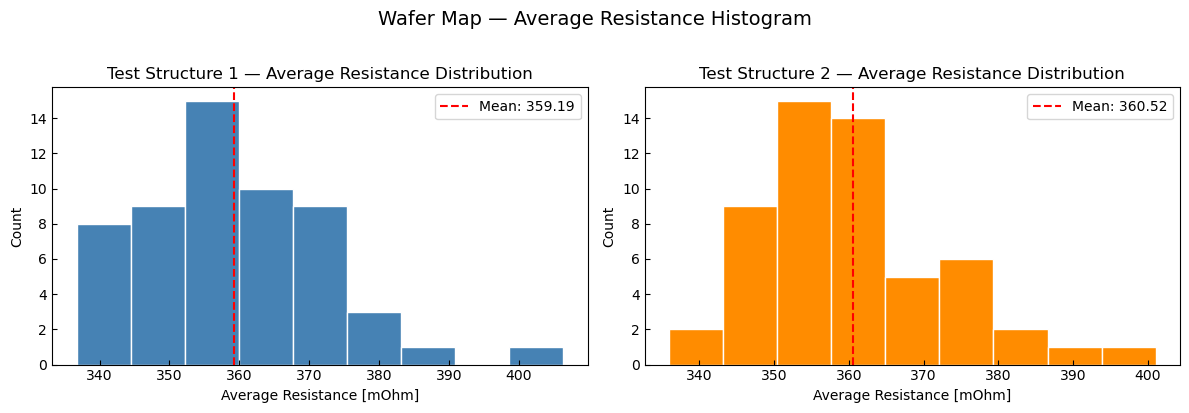

In [6]:
# ---------------------------------------------------------------------------
# Histograms of average resistance (Device 1 and Device 2)
# ---------------------------------------------------------------------------
vals_dev1 = grid_dev1[~np.isnan(grid_dev1) & ~bad_mask_dev1].flatten()
vals_dev2 = grid_dev2[~np.isnan(grid_dev2) & ~bad_mask_dev2].flatten()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(vals_dev1, bins='auto', color='steelblue', edgecolor='white')
ax1.set_title("Test Structure 1 — Average Resistance Distribution")
ax1.set_xlabel("Average Resistance [mOhm]")
ax1.set_ylabel("Count")
ax1.tick_params(axis='both', which='both', direction='in')
ax1.axvline(np.mean(vals_dev1), color='red', linestyle='--', linewidth=1.5, label=f"Mean: {np.mean(vals_dev1):.2f}")
ax1.legend()

ax2.hist(vals_dev2, bins='auto', color='darkorange', edgecolor='white')
ax2.set_title("Test Structure 2 — Average Resistance Distribution")
ax2.set_xlabel("Average Resistance [mOhm]")
ax2.set_ylabel("Count")
ax2.tick_params(axis='both', which='both', direction='in')
ax2.axvline(np.mean(vals_dev2), color='red', linestyle='--', linewidth=1.5, label=f"Mean: {np.mean(vals_dev2):.2f}")
ax2.legend()

fig.suptitle("Wafer Map — Average Resistance Histogram", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


C:\Users\Gabe\AppData\Local\Temp\ipykernel_3648\3469189196.py:77: UserWarning: Warning: converting a masked element to nan.
  if math.isnan(data[i, j]):
C:\Users\Gabe\AppData\Local\Temp\ipykernel_3648\3469189196.py:77: UserWarning: Warning: converting a masked element to nan.
  if math.isnan(data[i, j]):


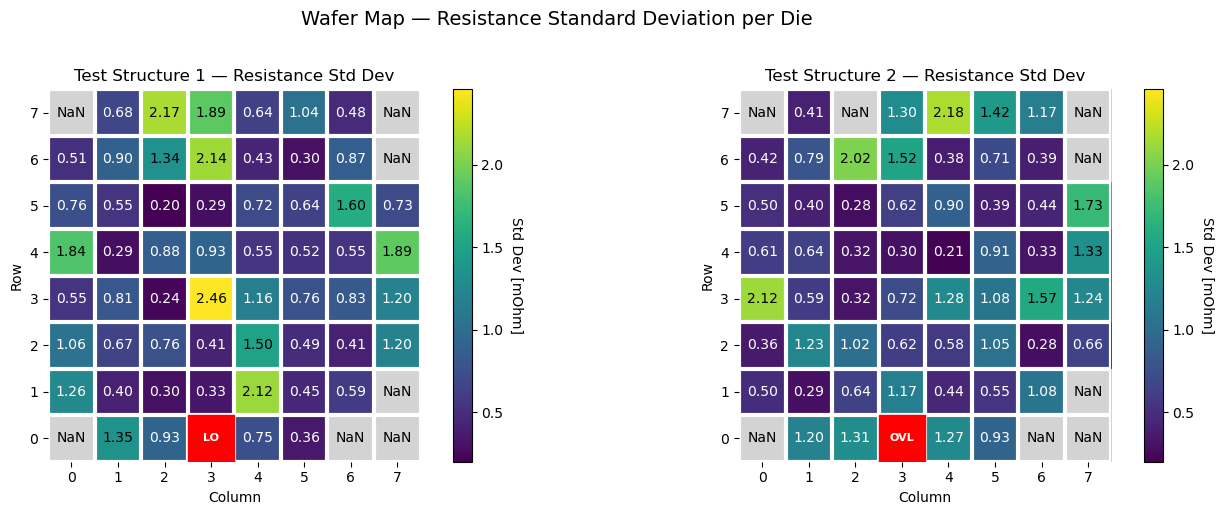

In [7]:
# ---------------------------------------------------------------------------
# Standard deviation wafer maps
# ---------------------------------------------------------------------------
std_dev1 = np.full((n_rows, n_cols), np.nan)
std_dev2 = np.full((n_rows, n_cols), np.nan)

for (row, col, device), std_res in std_data.items():
    ri = row_idx[row]
    ci = col_idx[col]
    if device == 1:
        std_dev1[ri, ci] = std_res
    elif device == 2:
        std_dev2[ri, ci] = std_res

# Convert Ohm → mOhm
std_dev1 = std_dev1 * 1000
std_dev2 = std_dev2 * 1000

cmap_std = mpl.colormaps.get_cmap('viridis').copy()
cmap_std.set_bad(color='lightgrey')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

vmin1, vmax1 = valid_range(std_dev1, bad_mask_dev1)
vmin2, vmax2 = valid_range(std_dev2, bad_mask_dev2)
vmin = min(vmin1, vmin2)
vmax = max(vmax1, vmax2)

im1, cbar1 = heatmap(std_dev1, all_rows, all_cols, ax=ax1,
                     cbarlabel="Std Dev [mOhm]", cmap=cmap_std,
                     vmin=vmin, vmax=vmax)
annotate_heatmap(im1, valfmt="{x:.2f}", skip_mask=bad_mask_dev1)
add_outlier_patches(ax1, outlier_mask_dev1)
add_outlier_patches(ax1, underrange_mask_dev1, label="LO")
ax1.set_title("Test Structure 1 — Resistance Std Dev")

im2, cbar2 = heatmap(std_dev2, all_rows, all_cols, ax=ax2,
                     cbarlabel="Std Dev [mOhm]", cmap=cmap_std,
                     vmin=vmin, vmax=vmax)
annotate_heatmap(im2, valfmt="{x:.2f}", skip_mask=bad_mask_dev2)
add_outlier_patches(ax2, outlier_mask_dev2)
add_outlier_patches(ax2, underrange_mask_dev2, label="LO")
ax2.set_title("Test Structure 2 — Resistance Std Dev")

fig.suptitle("Wafer Map — Resistance Standard Deviation per Die", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


C:\Users\Gabe\AppData\Local\Temp\ipykernel_3648\3469189196.py:77: UserWarning: Warning: converting a masked element to nan.
  if math.isnan(data[i, j]):
C:\Users\Gabe\AppData\Local\Temp\ipykernel_3648\3469189196.py:77: UserWarning: Warning: converting a masked element to nan.
  if math.isnan(data[i, j]):


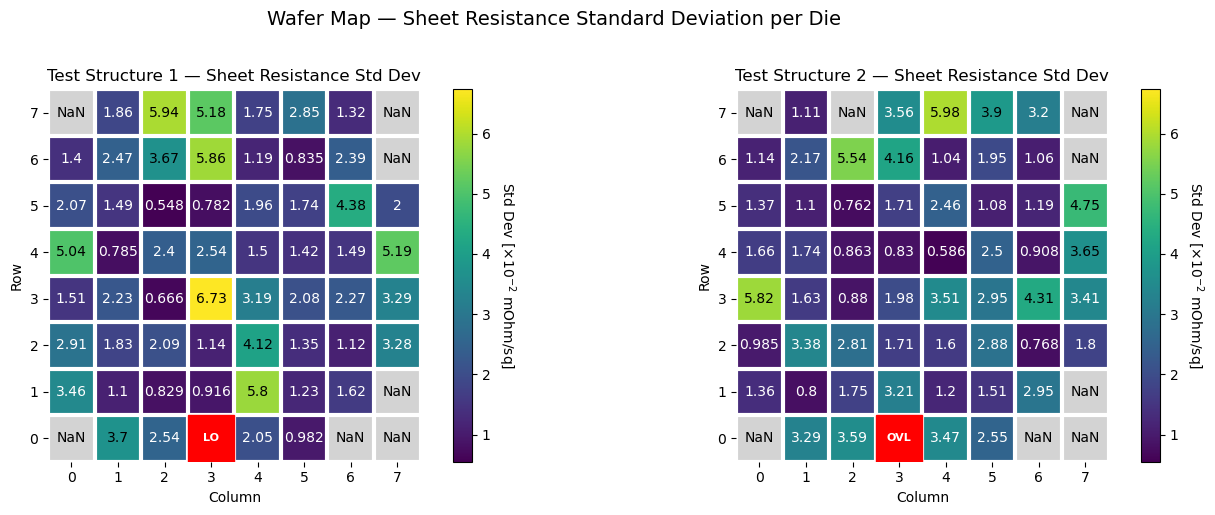

In [8]:
# ---------------------------------------------------------------------------
# Sheet resistance standard deviation wafer maps  (std_Rs = std_R * W/L)
# ---------------------------------------------------------------------------
std_rs_dev1 = std_dev1 * CORRECTION
std_rs_dev2 = std_dev2 * CORRECTION

# Compute a common display scale so annotations stay compact (max value → [1, 10))
valid_rs_std = np.concatenate([
    std_rs_dev1[~np.isnan(std_rs_dev1) & ~bad_mask_dev1].flatten(),
    std_rs_dev2[~np.isnan(std_rs_dev2) & ~bad_mask_dev2].flatten()
])
scale_exp = int(-np.floor(np.log10(np.nanmax(valid_rs_std)))) if len(valid_rs_std) > 0 else 0
scale = 10 ** scale_exp

std_rs_plot1 = std_rs_dev1 * scale
std_rs_plot2 = std_rs_dev2 * scale

cmap_std_rs = mpl.colormaps.get_cmap('viridis').copy()
cmap_std_rs.set_bad(color='lightgrey')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

vmin1, vmax1 = valid_range(std_rs_plot1, bad_mask_dev1)
vmin2, vmax2 = valid_range(std_rs_plot2, bad_mask_dev2)
vmin = min(vmin1, vmin2)
vmax = max(vmax1, vmax2)

cbarlabel = f"Std Dev [$\\times 10^{{{-scale_exp}}}$ mOhm/sq]"

im1, cbar1 = heatmap(std_rs_plot1, all_rows, all_cols, ax=ax1,
                     cbarlabel=cbarlabel, cmap=cmap_std_rs,
                     vmin=vmin, vmax=vmax)
annotate_heatmap(im1, valfmt="{x:.3g}", skip_mask=bad_mask_dev1)
add_outlier_patches(ax1, outlier_mask_dev1)
add_outlier_patches(ax1, underrange_mask_dev1, label="LO")
ax1.set_title("Test Structure 1 — Sheet Resistance Std Dev")

im2, cbar2 = heatmap(std_rs_plot2, all_rows, all_cols, ax=ax2,
                     cbarlabel=cbarlabel, cmap=cmap_std_rs,
                     vmin=vmin, vmax=vmax)
annotate_heatmap(im2, valfmt="{x:.3g}", skip_mask=bad_mask_dev2)
add_outlier_patches(ax2, outlier_mask_dev2)
add_outlier_patches(ax2, underrange_mask_dev2, label="LO")
ax2.set_title("Test Structure 2 — Sheet Resistance Std Dev")

fig.suptitle("Wafer Map — Sheet Resistance Standard Deviation per Die", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


In [9]:
import pandas as pd

# ---------------------------------------------------------------------------
# Summary statistics table
# ---------------------------------------------------------------------------
def die_stats(grid, rs_grid, std_grid, std_rs_grid, bad_mask, outlier_mask, underrange_mask):
    total = int(np.sum(~np.isnan(grid)))               # dies with any measurement
    n_ovl = int(np.sum(outlier_mask))
    n_lo  = int(np.sum(underrange_mask))
    n_missing = int(np.sum(np.isnan(grid)))
    n_valid = int(np.sum(~np.isnan(grid) & ~bad_mask))

    valid = ~np.isnan(grid) & ~bad_mask

    mean_r    = float(np.nanmean(grid[valid]))
    std_r     = float(np.nanstd(grid[valid]))          # die-to-die uniformity
    mean_rs   = float(np.nanmean(rs_grid[valid]))
    std_rs    = float(np.nanstd(rs_grid[valid]))

    # average of per-die within-measurement std devs (repeatability)
    mean_intradie_std    = float(np.nanmean(std_grid[valid]))
    mean_intradie_std_rs = float(np.nanmean(std_rs_grid[valid]))

    return {
        "Valid Dies":                    n_valid,
        "OVL Dies":                      n_ovl,
        "LO Dies":                       n_lo,
        "Missing Dies":                  n_missing,
        "Mean Resistance [mOhm]":        round(mean_r,  4),
        "Std Resistance (die-to-die) [mOhm]": round(std_r, 4),
        "Mean Sheet Resistance [mOhm/sq]":    round(mean_rs, 4),
        "Std Sheet Resistance (die-to-die) [mOhm/sq]": round(std_rs, 4),
        "Mean Within-Die Std Dev [mOhm]":     round(mean_intradie_std, 4),
        "Mean Within-Die Rs Std Dev [mOhm/sq]": round(mean_intradie_std_rs, 6),
    }

rows = {
    "Test Structure 1": die_stats(grid_dev1, grid_rs_dev1, std_dev1, std_rs_dev1,
                          bad_mask_dev1, outlier_mask_dev1, underrange_mask_dev1),
    "Test Structure 2": die_stats(grid_dev2, grid_rs_dev2, std_dev2, std_rs_dev2,
                          bad_mask_dev2, outlier_mask_dev2, underrange_mask_dev2),
}

df = pd.DataFrame(rows).T
display(df)


,Valid Dies,OVL Dies,LO Dies,Missing Dies,Mean Resistance [mOhm],Std Resistance (die-to-die) [mOhm],Mean Sheet Resistance [mOhm/sq],Std Sheet Resistance (die-to-die) [mOhm/sq],Mean Within-Die Std Dev [mOhm],Mean Within-Die Rs Std Dev [mOhm/sq]
Test Structure 1,56.0,0.0,1.0,7.0,359.1891,12.8538,9.8408,0.3522,0.8871,0.024305
Test Structure 2,55.0,1.0,0.0,8.0,360.5223,12.1875,9.8773,0.3339,0.8500,0.023287
